# Question 2
### What is the average height of the players?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

IN_DIR = "cleaned_data"

home = pd.read_parquet(f"{IN_DIR}/home_team.parquet")
away = pd.read_parquet(f"{IN_DIR}/away_team.parquet")

players_long = pd.concat([home, away], ignore_index=True)

In [2]:
players_unique = players_long.drop_duplicates(subset="player_id").reset_index(drop=True)
print(f"Unique players: {len(players_unique)}")

Unique players: 2644


### Coverage check: how many players actually have a height value?

In [3]:
has_height = players_unique["height"].notna().sum()
missing_height = players_unique["height"].isna().sum()
coverage_pct = has_height / len(players_unique) * 100

print(f"Players with a recorded height: {has_height} ({coverage_pct:.1f}%)")
print(f"Players with NO recorded height: {missing_height} ({100 - coverage_pct:.1f}%)")

Players with a recorded height: 1317 (49.8%)
Players with NO recorded height: 1327 (50.2%)


In [4]:
heights = players_unique["height"].dropna()
avg_height = heights.mean()
median_height = heights.median()

print(f"Answer to Question 2:")
print(f"Average height: {avg_height:.3f} meters (based on {len(heights)} players)")
print(f"Median height:  {median_height:.3f} meters")
print("NOTE: height is stored in METERS in this dataset, not centimeters.")

Answer to Question 2:
Average height: 1.821 meters (based on 1317 players)
Median height:  1.830 meters
NOTE: height is stored in METERS in this dataset, not centimeters.


#### =======================================================================
##### Chart -- distribution of player heights
##### Goal: an average alone hides the shape of the data. A histogram shows, whether height is roughly symmetric (a simple mean is trustworthy)
##### or skewed/bimodal (e.g. due to mixing men's and women's heights together).
#### =======================================================================

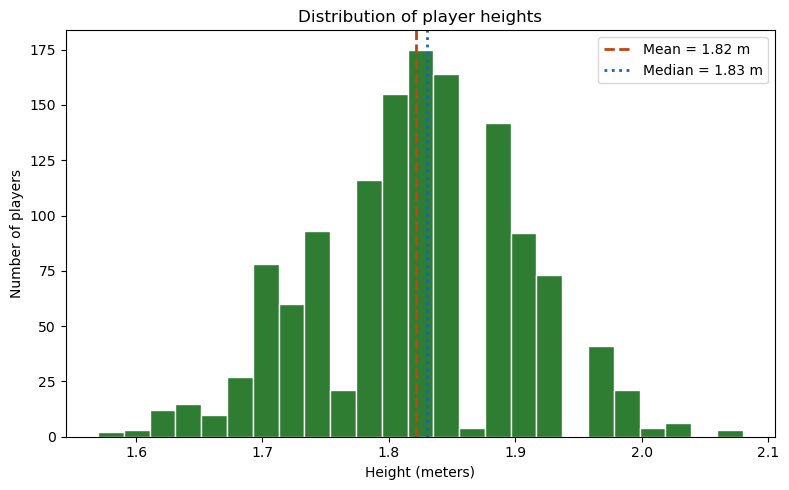

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(heights, bins=25, color="#2e7d32", edgecolor="white")
plt.axvline(avg_height, color="#c1440e", linestyle="--", linewidth=2,
            label=f"Mean = {avg_height:.2f} m")
plt.axvline(median_height, color="#1565c0", linestyle=":", linewidth=2,
            label=f"Median = {median_height:.2f} m")
plt.title("Distribution of player heights")
plt.xlabel("Height (meters)")
plt.ylabel("Number of players")
plt.legend()
plt.tight_layout()
plt.savefig('charts/q2_Distribution of player heights.png', dpi=200)
plt.show()

### Height vs. ranking: is there a relationship?

In [6]:
print("Unique gender values found:", players_unique["gender"].dropna().unique())
gender_colors = {"M": "#1565c0", "F": "#ad1457"}

Unique gender values found: <StringArray>
['M', 'F']
Length: 2, dtype: string


###  Height stats per gender 

In [7]:
height_by_gender = players_unique.dropna(subset=["height", "gender"]).groupby("gender")["height"]
print("\nHeight statistics by gender:")
print(height_by_gender.describe())


Height statistics by gender:
         count      mean       std   min  25%   50%   75%   max
gender                                                         
F        256.0  1.732227  0.061409  1.57  1.7  1.73  1.78  1.90
M       1060.0  1.842943  0.069150  1.57  1.8  1.85  1.88  2.08


#### Chart 1 -- Overlaid histograms
#### Goal: if the two colored distributions are clearly separated (not overlapping much), that confirms gender is the main driver of the earlier single-histogram's shape, and reporting one overall average alone would be misleading.

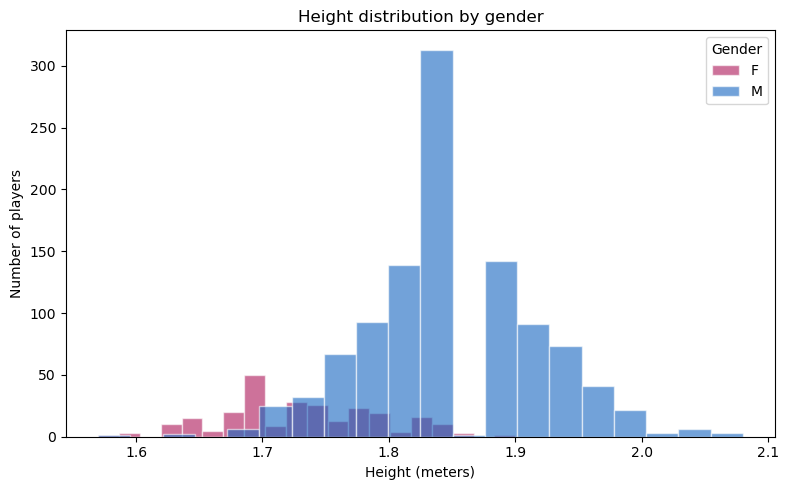

In [8]:
plt.figure(figsize=(8, 5))
for gender, group in height_by_gender:
    color = gender_colors.get(gender, "#757575")
    plt.hist(group, bins=20, alpha=0.6, label=str(gender), color=color, edgecolor="white")
plt.title("Height distribution by gender")
plt.xlabel("Height (meters)")
plt.ylabel("Number of players")
plt.legend(title="Gender")
plt.tight_layout()
plt.savefig('charts/q2_Height distribution by gender', dpi=200)
plt.show()

#### =======================================================================
#### Chart 2 -- Side-by-side boxplot
#### Goal: a compact summary of the same comparison -- median, spread,
#### and outliers per gender, easier to read precisely than overlaid bars.
#### =======================================================================

C:\Users\QR\AppData\Local\Temp\ipykernel_8048\2618596373.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)


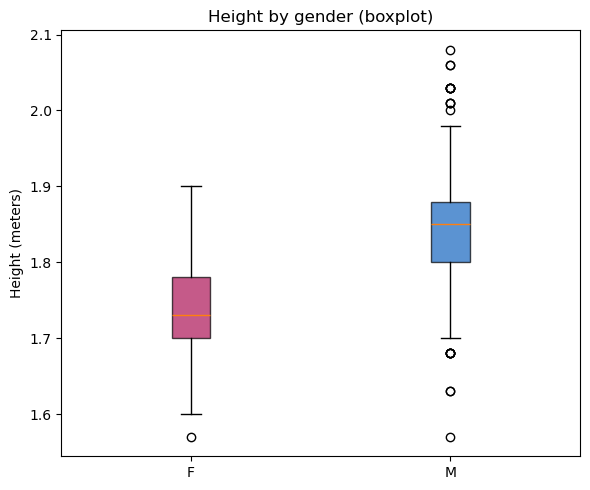

In [9]:
plot_data = [group.values for _, group in height_by_gender]
labels = [str(g) for g, _ in height_by_gender]
box_colors = [gender_colors.get(g, "#757575") for g in labels]

fig, ax = plt.subplots(figsize=(6, 5))
bp = ax.boxplot(plot_data, labels=labels, patch_artist=True)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Height by gender (boxplot)")
ax.set_ylabel("Height (meters)")
plt.tight_layout()
plt.savefig('charts/q2_Height by gender', dpi=200)
plt.show()

#### =======================================================================
### FINDINGS SUMMARY -- Question 2 (extended, by gender)
### =======================================================================

### Question 2:What is the average height of the players? 

### Results:
  Women: mean 1.732 m, median 1.73 m, std 0.061 (n=256)
  Men:   mean 1.843 m, median 1.85 m, std 0.069 (n=1,060)
  Overall (mixed): mean 1.82 m

### Interpretation:
There is a clear ~11 cm gap between the average heights of men and women in this dataset,
consistent with known real-world averages in professional tennis (WTA ~1.70-1.75 m, ATP ~1.85 m).

### The overlaid histogram confirms the distribution is genuinely bimodal:
a smaller cluster of women around 1.65-1.75 m and a larger cluster of men around 1.78-1.95 m, with modest overlap in between.
This explains why the earlier single combined histogram looked broader/less clean than a typical single bell curve -- it was actually a mixture of two separate populations.

The overall mixed average (1.82 m) sits much closer to the men's mean than the women's, simply because men (1,060) outnumber women (256) roughly 4-to-1 in this height-available subset -- NOT because men's height "matters more". Reporting a single overall average without noting this imbalance would be misleading.

Standard deviations are similar between genders (0.061 vs 0.069),
meaning the within-group spread is comparable -- the main difference is a shift in the mean, not a difference in variability.

### Side observation:
the boxplot shows several low outliers in the men's group (around 1.57-1.68 m), unusually short for professional male players, though this was not confirmed as an error.
